In [39]:
import pandas as pd
import numpy as np
import sklearn
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
wait_times = pd.read_csv('../data/modern_api_wait_times.csv').drop(columns=['id'])

In [79]:
def bucket_time(t):
    hour = int(t.split(':')[0])
    if 8 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    elif 21 <= hour <= 23:
        return 'Night'

def open_hours(row):
    hour = int(row['time'].split(':')[0])
    if row['park'] == "Disneyland":
        if hour < 8:
            return "non-park_hours"
        else:
            return "open"
    elif row['park'] == "Six Flags Magic Mountain":
        if hour < 11 or hour >= 20:
            return "non-park_hours"
        else:
            return "open"
    elif row['park'] == "Disney California Adventure":
        if hour < 8 or hour >= 22:
            return "non-park_hours"
        else:
            return "open"
    elif row['park'] == "Knott' Berry Farm":
        if row['day_of_week'] in ['Saturday', "Friday"]:
            if hour < 10 or hour >= 22:
                return "non-park_hours"
            else:
                return "open"
        elif row['day_of_week'] in ['Sunday']:
            if hour < 10 or hour >= 21:
                return "non-park_hours"
            else:
                return "open"
        elif row['day_of_week'] in ['Thursday']:
            if hour < 10 or hour >= 20:
                return "non-park_hours"
            else:
                return "open"
        else:
            if hour < 11 or hour >= 18:
                return "non-park_hours"
            else:
                return "open"
    elif row['park'] == "Universal Studios Hollywood":
        if hour < 9 or hour >= 20:
            return "non-park_hours"
        else:
            return "open" 
        
wait_times_temporal = wait_times.copy()
wait_times_temporal = wait_times_temporal[['wait_time', 'day_of_week', 'time', 'park']]
wait_times_temporal['time_bucket'] = wait_times_temporal['time'].apply(bucket_time)
wait_times_temporal['park_open'] = wait_times_temporal.apply(open_hours, axis=1)
wait_times_temporal = wait_times_temporal[wait_times_temporal['park_open'] != 'non-park_hours']
wait_times_temporal = wait_times_temporal.drop(columns=['time', 'park_open', "park"])
wait_times_temporal['time_bucket'] = pd.Categorical(wait_times_temporal['time_bucket'], categories= ["Morning", "Afternoon", "Evening", "Night"], ordered=True)

wait_times_temporal.head(5)

,wait_time,day_of_week,time_bucket
2275,0,Monday,Morning
2605,0,Monday,Morning
2606,0,Monday,Morning
2607,0,Monday,Morning
2608,0,Monday,Morning


In [80]:
wait_times_temporal_encoded = pd.get_dummies(wait_times_temporal, columns=["day_of_week", "time_bucket"], drop_first=True)
wait_times_temporal_encoded = wait_times_temporal_encoded.astype(int)

wait_times_temporal_encoded.head(5)

,wait_time,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,time_bucket_Afternoon,time_bucket_Evening,time_bucket_Night
2275,0,1,0,0,0,0,0,0,0,0
2605,0,1,0,0,0,0,0,0,0,0
2606,0,1,0,0,0,0,0,0,0,0
2607,0,1,0,0,0,0,0,0,0,0
2608,0,1,0,0,0,0,0,0,0,0


In [81]:

X = wait_times_temporal_encoded.drop(columns=['wait_time'])
y = wait_times_temporal_encoded['wait_time']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              wait_time   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     2685.
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        14:42:48   Log-Likelihood:            -4.5705e+05
No. Observations:              116496   AIC:                         9.141e+05
Df Residuals:                  116486   BIC:                         9.142e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.87

C:\Users\mikec\AppData\Local\Temp\ipykernel_17908\1328567430.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = wait_times_temporal.pivot_table(


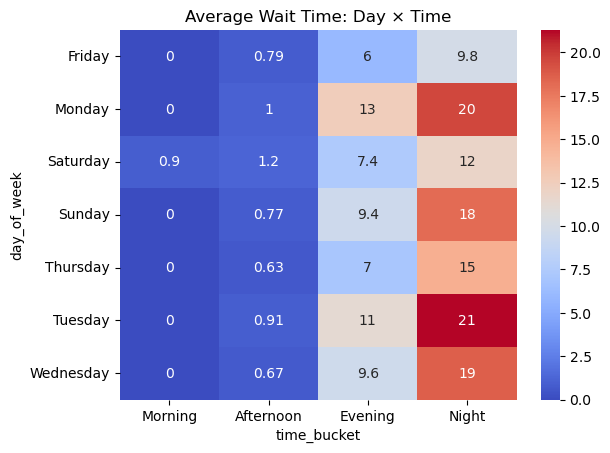

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = wait_times_temporal.pivot_table(
    values='wait_time',
    index='day_of_week',
    columns='time_bucket',
    aggfunc='mean'
)

sns.heatmap(pivot, cmap='coolwarm', annot=True)
plt.title("Average Wait Time: Day × Time")
plt.show()
